# Notebook 07 — Visualisations MiniGrid-MemoryS7

Ce notebook produit les **visualisations** des agents entraînés dans NB 06.

## La tâche en 3 phases

1. **Phase 1 — La salle de départ** : l'agent (triangle rouge) voit un objet "indice" (clé colorée) dans une petite chambre.
2. **Phase 2 — Le couloir** : l'agent traverse un couloir de 5-7 pas où l'objet sort de son champ de vision (7×7 local).
3. **Phase 3 — Le choix** : à la fin, l'agent doit choisir entre 2 objets celui qui correspond à la couleur initiale.

**Récompense** : ~1.0 si succès, 0 si échec ou timeout. C'est un POMDP à **mémoire longue** : l'indice n'est plus visible quand il faut s'en servir.

## Setup

In [1]:
# !pip install -q minigrid imageio imageio-ffmpeg

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import minigrid
import imageio
from IPython.display import Image, display
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt

from src.envs.minigrid_wrappers import FlatMiniGridWrapper
from src.envs.pomdp_wrappers import FrameStackWrapper
from src.agents.ppo_lstm import AgentLSTM

VIDEO_DIR = ROOT / "results" / "videos"
MODEL_DIR = ROOT / "results" / "models"
FIG_DIR = ROOT / "report" / "figures"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"\nModèles MiniGrid disponibles :")
for p in sorted(MODEL_DIR.glob("*minigrid*.pt")):
    print(f"  - {p.name}")

c:\Users\Pape Malick\works\ppo-recurrent-pomdp\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cpu

Modèles MiniGrid disponibles :
  - ppo_framestack_minigrid_memory__seed1.pt
  - ppo_lstm_minigrid_memory__seed1.pt
  - ppo_mlp_minigrid_memory__seed1.pt


## Classe AgentMLP pour MiniGrid (architecture du NB 06)

In [2]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class AgentMLPMiniGrid(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=128):
        super().__init__()
        self.network = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.ReLU(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.ReLU(),
        )
        self.actor = layer_init(nn.Linear(hidden_size, n_actions), std=0.01)
        self.critic = layer_init(nn.Linear(hidden_size, 1), std=1.0)
    def forward_policy(self, x):
        return self.actor(self.network(x))

## 1. Vue statique de l'environnement (figure pour le rapport)

Mission : go to the matching object at the end of the hallway


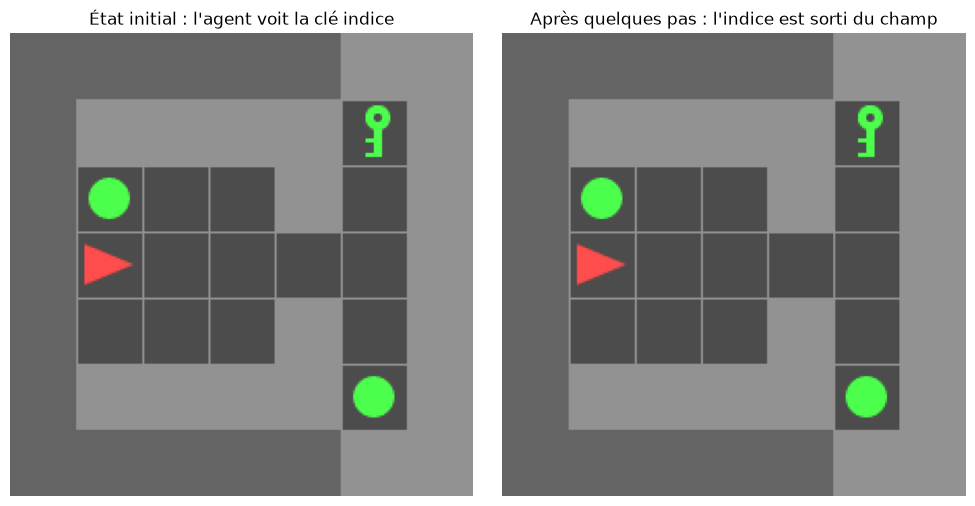

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\minigrid_task_illustration.png


In [3]:
env = gym.make("MiniGrid-MemoryS7-v0", render_mode="rgb_array")
obs, _ = env.reset(seed=42)
initial_view = env.render()
print(f"Mission : {env.unwrapped.mission}")

# Quelques pas pour montrer "milieu du couloir"
for _ in range(5):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    if term or trunc: break
mid_view = env.render()
env.close()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(initial_view)
axes[0].set_title("État initial : l'agent voit la clé indice")
axes[0].axis("off")
axes[1].imshow(mid_view)
axes[1].set_title("Après quelques pas : l'indice est sorti du champ")
axes[1].axis("off")
plt.tight_layout()
fig_path = FIG_DIR / "minigrid_task_illustration.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure → {fig_path}")

## 2. Fonctions de rollout

In [4]:
def record_episode_mlp(agent, use_framestack=False, seed=42, max_steps=200, deterministic=True):
    env_raw = gym.make("MiniGrid-MemoryS7-v0", render_mode="rgb_array")
    env = FlatMiniGridWrapper(env_raw)
    if use_framestack:
        env = FrameStackWrapper(env, k=4)
    obs, _ = env.reset(seed=seed)
    frames = [env_raw.render()]
    total_r = 0
    for _ in range(max_steps):
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = agent.forward_policy(obs_t)
            if deterministic:
                action = int(logits.argmax(dim=-1).item())
            else:
                action = int(Categorical(logits=logits).sample().item())
        obs, r, term, trunc, _ = env.step(action)
        frames.append(env_raw.render())
        total_r += r
        if term or trunc: break
    env.close()
    return frames, float(total_r)


def record_episode_lstm(agent, seed=42, max_steps=200, deterministic=True):
    env_raw = gym.make("MiniGrid-MemoryS7-v0", render_mode="rgb_array")
    env = FlatMiniGridWrapper(env_raw)
    obs, _ = env.reset(seed=seed)
    lstm_state = agent.initial_state(batch_size=1, device=device)
    next_done = torch.zeros(1, device=device)
    frames = [env_raw.render()]
    total_r = 0
    for _ in range(max_steps):
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            hidden, lstm_state = agent.get_states(obs_t, lstm_state, next_done)
            logits = agent.actor(hidden)
            if deterministic:
                action = int(logits.argmax(dim=-1).item())
            else:
                action = int(Categorical(logits=logits).sample().item())
        obs, r, term, trunc, _ = env.step(action)
        frames.append(env_raw.render())
        total_r += r
        next_done = torch.tensor([float(term or trunc)], device=device)
        if term or trunc: break
    env.close()
    return frames, float(total_r)


def save_gif(frames, path, fps=5, max_frames=80):
    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames)-1, max_frames).astype(int)
        frames = [frames[i] for i in idx]
    imageio.mimsave(path, frames, fps=fps, loop=0)
    print(f"  → {path.name} ({len(frames)} frames)")

## 3. Démo PPO-MLP (sans mémoire)

PPO-MLP : retour = 0.978, longueur = 7
  → minigrid_01_mlp.gif (7 frames)


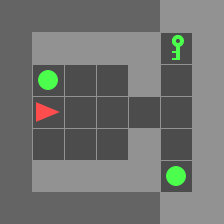

In [5]:
model_path = MODEL_DIR / "ppo_mlp_minigrid_memory__seed1.pt"
assert model_path.exists(), f"Modele manquant: {model_path}"

agent_mlp = AgentMLPMiniGrid(obs_dim=147, n_actions=7).to(device)
agent_mlp.load_state_dict(torch.load(model_path, map_location=device))
agent_mlp.eval()

frames, r = record_episode_mlp(agent_mlp, use_framestack=False, seed=42)
print(f"PPO-MLP : retour = {r:.3f}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "minigrid_01_mlp.gif")
display(Image(filename=str(VIDEO_DIR / "minigrid_01_mlp.gif")))

## 4. Démo PPO-MLP + FrameStack

PPO+FrameStack : retour = 0.000, longueur = 7
  → minigrid_02_framestack.gif (7 frames)


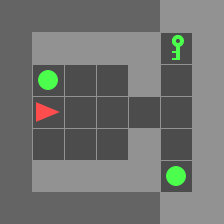

In [6]:
model_path = MODEL_DIR / "ppo_framestack_minigrid_memory__seed1.pt"
assert model_path.exists(), f"Modele manquant: {model_path}"

agent_fs = AgentMLPMiniGrid(obs_dim=4*147, n_actions=7).to(device)
agent_fs.load_state_dict(torch.load(model_path, map_location=device))
agent_fs.eval()

frames, r = record_episode_mlp(agent_fs, use_framestack=True, seed=42)
print(f"PPO+FrameStack : retour = {r:.3f}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "minigrid_02_framestack.gif")
display(Image(filename=str(VIDEO_DIR / "minigrid_02_framestack.gif")))

## 5. Démo PPO-LSTM ⭐

PPO-LSTM : retour = 0.000, longueur = 7
  → minigrid_03_lstm.gif (7 frames)


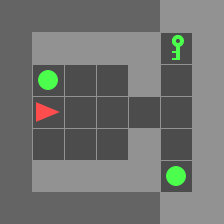

In [7]:
model_path = MODEL_DIR / "ppo_lstm_minigrid_memory__seed1.pt"
assert model_path.exists(), f"Modele manquant: {model_path}"

agent_lstm = AgentLSTM(obs_dim=147, n_actions=7, hidden_size=128, lstm_hidden_size=128).to(device)
agent_lstm.load_state_dict(torch.load(model_path, map_location=device))
agent_lstm.eval()

frames, r = record_episode_lstm(agent_lstm, seed=42)
print(f"PPO-LSTM : retour = {r:.3f}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "minigrid_03_lstm.gif")
display(Image(filename=str(VIDEO_DIR / "minigrid_03_lstm.gif")))

## 6. Comparaison côte-à-côte ⭐⭐

Génération des 3 trajectoires...
  PPO-MLP : retour = 0.989
  PPO+FrameStack : retour = 0.000
  PPO-LSTM : retour = 0.000
  → minigrid_04_comparison.gif (4 frames)

Gauche : MLP | Milieu : FrameStack | Droite : LSTM
Retours : 0.99 | 0.00 | 0.00


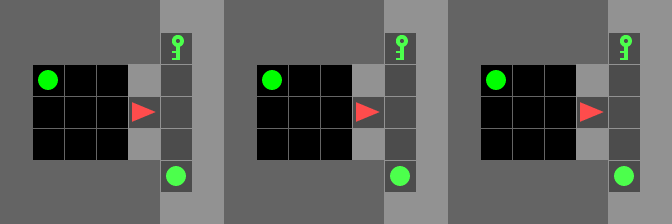

In [8]:
SEED_VIZ = 7
print("Génération des 3 trajectoires...")
frames_mlp, r_mlp = record_episode_mlp(agent_mlp, use_framestack=False, seed=SEED_VIZ)
print(f"  PPO-MLP : retour = {r_mlp:.3f}")
frames_fs, r_fs = record_episode_mlp(agent_fs, use_framestack=True, seed=SEED_VIZ)
print(f"  PPO+FrameStack : retour = {r_fs:.3f}")
frames_lstm, r_lstm = record_episode_lstm(agent_lstm, seed=SEED_VIZ)
print(f"  PPO-LSTM : retour = {r_lstm:.3f}")

max_len = max(len(frames_mlp), len(frames_fs), len(frames_lstm))
def pad(frames, target_len):
    if len(frames) < target_len:
        return frames + [frames[-1]] * (target_len - len(frames))
    return frames[:target_len]

combined = []
for fa, fb, fc in zip(pad(frames_mlp, max_len), pad(frames_fs, max_len), pad(frames_lstm, max_len)):
    combined.append(np.concatenate([fa, fb, fc], axis=1))

save_gif(combined, VIDEO_DIR / "minigrid_04_comparison.gif", fps=4)
print(f"\nGauche : MLP | Milieu : FrameStack | Droite : LSTM")
print(f"Retours : {r_mlp:.2f} | {r_fs:.2f} | {r_lstm:.2f}")
display(Image(filename=str(VIDEO_DIR / "minigrid_04_comparison.gif")))

## 7. Évaluation quantitative sur 30 épisodes

In [9]:
def evaluate_mlp(agent, use_framestack=False, n_episodes=30):
    rets = []
    for ep in range(n_episodes):
        env = FlatMiniGridWrapper(gym.make("MiniGrid-MemoryS7-v0"))
        if use_framestack:
            env = FrameStackWrapper(env, k=4)
        obs, _ = env.reset(seed=1000 + ep)
        total_r = 0
        for _ in range(200):
            with torch.no_grad():
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(agent.forward_policy(obs_t).argmax(dim=-1).item())
            obs, r, term, trunc, _ = env.step(action)
            total_r += r
            if term or trunc: break
        rets.append(total_r); env.close()
    return rets


def evaluate_lstm(agent, n_episodes=30):
    rets = []
    for ep in range(n_episodes):
        env = FlatMiniGridWrapper(gym.make("MiniGrid-MemoryS7-v0"))
        obs, _ = env.reset(seed=1000 + ep)
        lstm_state = agent.initial_state(1, device)
        next_done = torch.zeros(1, device=device)
        total_r = 0
        for _ in range(200):
            with torch.no_grad():
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                hidden, lstm_state = agent.get_states(obs_t, lstm_state, next_done)
                action = int(agent.actor(hidden).argmax(dim=-1).item())
            obs, r, term, trunc, _ = env.step(action)
            total_r += r
            next_done = torch.tensor([float(term or trunc)], device=device)
            if term or trunc: break
        rets.append(total_r); env.close()
    return rets


print("Evaluation deterministe sur 30 episodes (seeds 1000-1029)...\n")
rets_mlp = evaluate_mlp(agent_mlp, False)
print(f"PPO-MLP        : {np.mean(rets_mlp):.3f} +/- {np.std(rets_mlp):.3f}  | succes : {sum(r>0 for r in rets_mlp)}/30")
rets_fs = evaluate_mlp(agent_fs, True)
print(f"PPO+FrameStack : {np.mean(rets_fs):.3f} +/- {np.std(rets_fs):.3f}  | succes : {sum(r>0 for r in rets_fs)}/30")
rets_lstm = evaluate_lstm(agent_lstm)
print(f"PPO-LSTM       : {np.mean(rets_lstm):.3f} +/- {np.std(rets_lstm):.3f}  | succes : {sum(r>0 for r in rets_lstm)}/30")

Evaluation deterministe sur 30 episodes (seeds 1000-1029)...

PPO-MLP        : 0.525 +/- 0.491  | succes : 16/30
PPO+FrameStack : 0.459 +/- 0.491  | succes : 14/30
PPO-LSTM       : 0.459 +/- 0.491  | succes : 14/30


## 8. Boxplot des évaluations

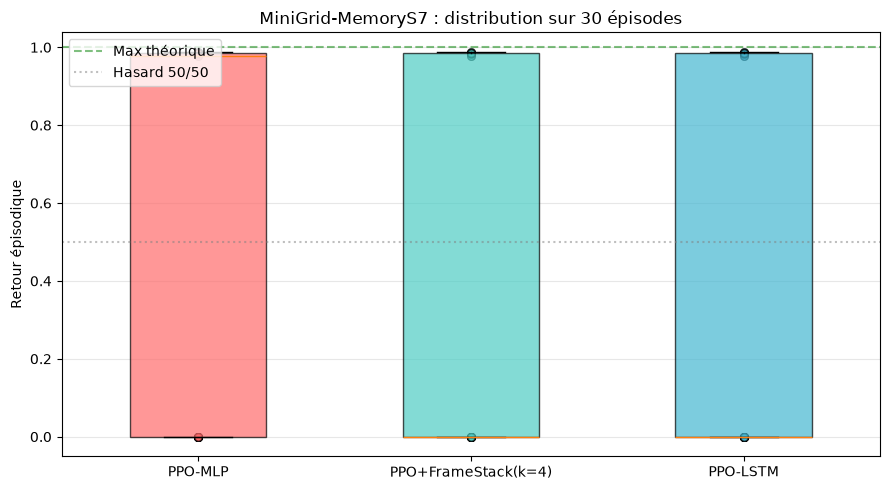

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\minigrid_eval_boxplot.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
data = [rets_mlp, rets_fs, rets_lstm]
labels = ['PPO-MLP', 'PPO+FrameStack(k=4)', 'PPO-LSTM']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, d in enumerate(data, 1):
    ax.scatter([i]*len(d), d, alpha=0.5, color=colors[i-1], s=30, edgecolor='black')

ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Max théorique')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Hasard 50/50')
ax.set_ylabel('Retour épisodique')
ax.set_title('MiniGrid-MemoryS7 : distribution sur 30 épisodes')
ax.legend(loc='upper left')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig_path = FIG_DIR / "minigrid_eval_boxplot.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure → {fig_path}")

## ✅ Récapitulatif des artefacts

| Fichier | Description |
|---|---|
| `report/figures/minigrid_task_illustration.png` | Illustration de la tâche (figure pour le rapport) |
| `results/videos/minigrid_01_mlp.gif` | Démo PPO-MLP |
| `results/videos/minigrid_02_framestack.gif` | Démo PPO+FrameStack |
| `results/videos/minigrid_03_lstm.gif` | Démo PPO-LSTM (réussite attendue) |
| `results/videos/minigrid_04_comparison.gif` | **Slide phare** — comparaison côte-à-côte |
| `report/figures/minigrid_eval_boxplot.png` | Boxplot des retours sur 30 épisodes |